Primer spodaj je navdihnjen [z originalnim vodičem o TensorFlow](https://www.tensorflow.org/tutorials/generative/style_transfer), kot tudi [s tem blog prispevkom](https://medium.com/mlreview/making-ai-art-with-style-transfer-using-keras-8bb5fa44b216). Drug dober primer prenosa sloga z uporabo CNTK ogrodja je [tukaj](https://github.com/Microsoft/CNTK/blob/master/Tutorials/CNTK_205_Artistic_Style_Transfer.ipynb). Tukaj je izvirni članek o [prenosu umetniškega sloga](https://arxiv.org/abs/1508.06576).

Glavne ideje za prenos sloga so naslednje:

* Začnemo z belo šumom in poskušamo optimizirati trenutno sliko $x$, da minimiziramo neko funkcijo izgube
* Funkcija izgube je sestavljena iz treh komponent $\mathcal{L(x)} = \alpha\mathcal{L}_c(x,i) + \beta\mathcal{L}_s(x,s)+\gamma\mathcal{L}_t(x)$
   - $\mathcal{L}_c$ - izguba vsebine - prikazuje, kako blizu je trenutna slika $x$ izvirni sliki $i$
   - $\mathcal{L}_s$ - izguba sloga - prikazuje, kako blizu je trenutna slika $x$ slogu slike $s$
   - $\mathcal{L}_t$ - izguba skupne variacije (te v našem primeru ne bomo obravnavali) - zagotavlja, da je končna slika gladka, tj. prikazuje povprečno kvadratno napako sosednjih pikslov slike $x$
   
Te funkcije izgube morajo biti zasnovane na pameten način, tako da na primer izguba sloga ustreza podobnosti slogov slik, ne pa dejanski vsebini. Za to bomo primerjali nekatere globlje sloje značilnosti CNN, ki analizira sliko.


Začnimo z nalaganjem nekaj slik:


In [1]:
!mkdir -p images
!curl https://cdn.pixabay.com/photo/2016/05/18/00/27/franz-marc-1399594_960_720.jpg > images/style.jpg
!curl https://upload.wikimedia.org/wikipedia/commons/thumb/b/bd/Golden_tabby_and_white_kitten_n01.jpg/1280px-Golden_tabby_and_white_kitten_n01.jpg > images/image.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  210k  100  210k    0     0  2670k      0 --:--:-- --:--:-- --:--:-- 2670k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  131k  100  131k    0     0   459k      0 --:--:-- --:--:-- --:--:--  459k


In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input
import IPython.display as display

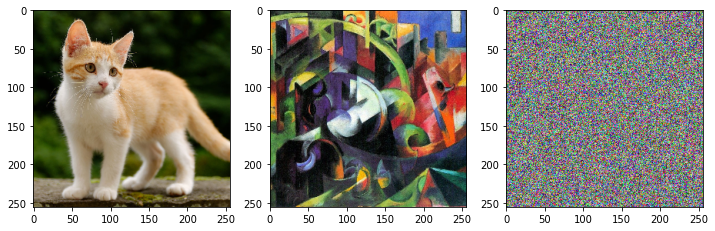

In [31]:
img_size = 256

def load_image(fn):
  x = cv2.imread(fn)
  return cv2.cvtColor(x, cv2.COLOR_BGR2RGB)

img_style = load_image('images/style.jpg')
img_content = load_image('images/image.jpg')
img_content = img_content[:,200:200+857,:]
img_content = cv2.resize(img_content,(img_size,img_size))
img_style = img_style[:,200:200+671,:]
img_style = cv2.resize(img_style,(img_size,img_size))

img_result = np.random.uniform(size=(img_size,img_size,3))

matplotlib.rcParams['figure.figsize'] = (12, 12)
matplotlib.rcParams['axes.grid'] = False

fig,ax = plt.subplots(1,3)
ax[0].imshow(img_content)
ax[1].imshow(img_style)
ax[2].imshow((255*img_result).astype(int))
plt.show()

Za izračun izgube sloga in vsebine moramo delovati v prostoru značilnosti, pridobljenem s CNN. Uporabimo lahko različne arhitekture CNN, vendar bomo zaradi enostavnosti v našem primeru izbrali VGG-19, predhodno usposobljen na *ImageNet*.


In [32]:
vgg = tf.keras.applications.VGG16(include_top=False, weights='imagenet')
vgg.trainable = False

Poglejmo si arhitekturo modela:


In [33]:
vgg.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, None, None, 128)   0     

Določimo funkcijo, ki nam bo omogočila izločanje vmesnih značilnosti iz omrežja VGG:


In [34]:
def layer_extractor(layers):
    outputs = [vgg.get_layer(x).output for x in layers]
    model = tf.keras.Model([vgg.input],outputs)
    return model 

## Izguba vsebine

**Izguba vsebine** prikazuje, kako blizu je naša trenutna slika $x$ izvirni sliki. Pregleduje vmesne sloje značilk v CNN in izračuna kvadratno napako. Izguba vsebine na sloju $l$ je definirana kot
$$
\mathcal{L}_c = {1\over2}\sum_{i,j} (F_{ij}^{(l)}-P_{ij}^{(l)})^2
$$
kjer sta $F^{(l)}$ in $P^{(l)}$ -- značilke na sloju $l$.


In [35]:
content_layers = ['block4_conv2'] 
content_extractor = layer_extractor(content_layers)

content_target = content_extractor(preprocess_input(tf.expand_dims(img_content,axis=0)))

def content_loss(img):
    z = content_extractor(preprocess_input(tf.expand_dims(255*img,axis=0))) 
    return 0.5*tf.reduce_sum((z-content_target)**2)

Zdaj bomo izvedli glavni trik prenosa sloga - **optimizacijo**. Začeli bomo z naključno sliko in nato uporabili optimizator TensorFlow, da prilagodimo to sliko za zmanjšanje izgube vsebine.

**Pomembno**: v našem primeru se vsi izračuni izvajajo z uporabo GPU-zavednega *TensorFlow* ogrodja, kar omogoča, da se ta koda izvaja veliko bolj učinkovito na GPU.


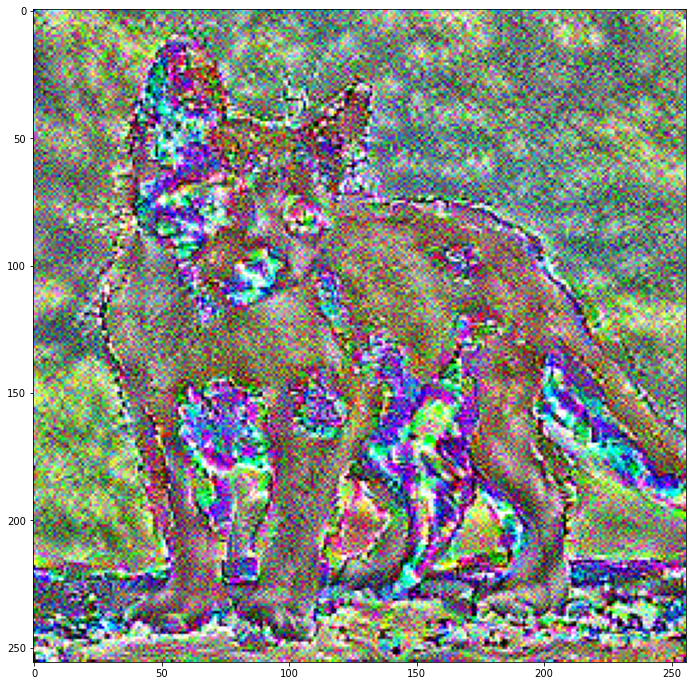

In [63]:
img = tf.Variable(img_result)
opt = tf.optimizers.Adam(learning_rate=0.002, beta_1=0.99, epsilon=1e-1)

clip = lambda x : tf.clip_by_value(x,clip_value_min=0,clip_value_max=1)

def optimize(img,loss_fn):
    with tf.GradientTape() as tape:
        loss = loss_fn(img)
    grad = tape.gradient(loss,img)
    opt.apply_gradients([(grad,img)])
    #img.assign(tf.clip_by_value(img,clip_value_min=0,clip_value_max=1))

def train(img,loss_fn,epochs=10,steps_per_epoch=100):
    for _ in range(epochs):
        display.clear_output(wait=True)
        plt.imshow((255*clip(img)).numpy().astype(int))
        plt.show()
        for _ in range(steps_per_epoch):
            optimize(img,loss_fn=loss_fn)

train(img,content_loss)

> **Vaja**: Poskusite eksperimentirati z različnimi sloji v mreži in opazujte, kaj se zgodi. Prav tako lahko poskusite optimizirati več slojev hkrati, vendar boste morali nekoliko spremeniti kodo za `content_loss`.

## Izguba sloga

Izguba sloga je glavna ideja za prenos sloga. Ne primerjamo dejanskih značilnosti, temveč njihove Gramove matrike, ki so definirane kot $$G=A\times A^T$$

Gramova matrika je podobna korelacijski matriki in prikazuje, kako so nekateri filtri odvisni od drugih. Izguba sloga se izračuna kot vsota izgub iz različnih slojev, ki so pogosto upoštevane z uteženimi koeficienti.

Skupna funkcija izgube za prenos sloga je vsota *izgube vsebine* in *izgube sloga*.


In [64]:
def gram_matrix(x):
  result = tf.linalg.einsum('bijc,bijd->bcd', x, x)
  input_shape = tf.shape(x)
  num_locations = tf.cast(input_shape[1]*input_shape[2], tf.float32)
  return result/(num_locations)

style_layers = ['block1_conv1','block2_conv1','block3_conv1','block4_conv1']

def style_extractor(img):
    return [gram_matrix(x) for x in layer_extractor(style_layers)(img)]

style_target = style_extractor(preprocess_input(tf.expand_dims(img_style,axis=0)))

def style_loss(img):
    z = style_extractor(preprocess_input(tf.expand_dims(255*img,axis=0)))
    loss = tf.add_n([tf.reduce_mean((x-target)**2) 
                           for x,target in zip(z,style_target)])
    return loss / len(style_layers)


## Združevanje vsega skupaj

Opredelili bomo funkcijo `total_loss`, ki bo izračunala skupno izgubo, in izvedli optimizacijo:


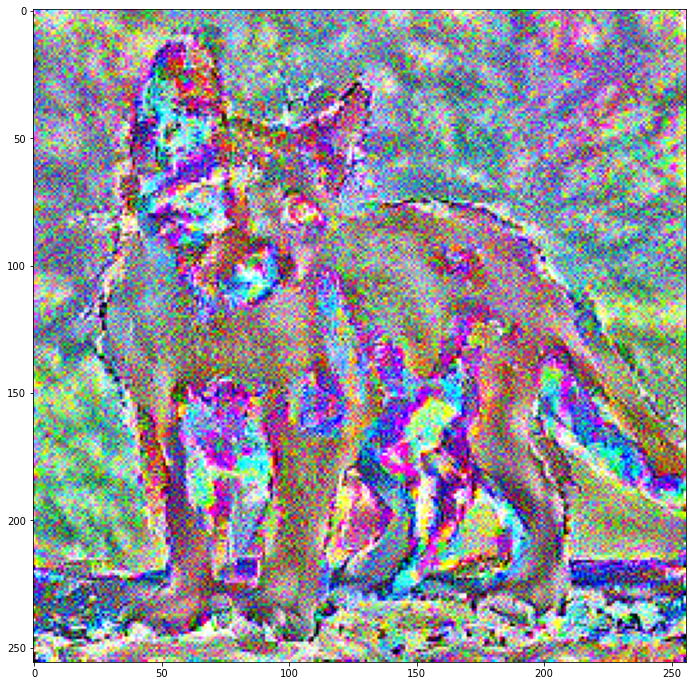

In [65]:
def total_loss(img):
    return 2*content_loss(img)+style_loss(img)

img.assign(img_result)

train(img,loss_fn=total_loss)

Koda spodaj izvaja dejansko optimizacijo izgube. Upoštevajte, da optimizacija kljub uporabi GPU zahteva precej časa. Celico spodaj lahko za izboljšanje rezultata zaženete večkrat.


## Dodaj izgubo variacije

**Izguba variacije** nam omogoča, da zmanjšamo šum na sliki, tako da minimiziramo razlike med sosednjimi piksli.

Optimizacijo bomo začeli z izvirno vsebinsko sliko, kar nam omogoča, da ohranimo več podrobnosti vsebine na sliki, ne da bi zapletli funkcijo izgube vsebine. Kljub temu bomo dodali nekaj šuma.


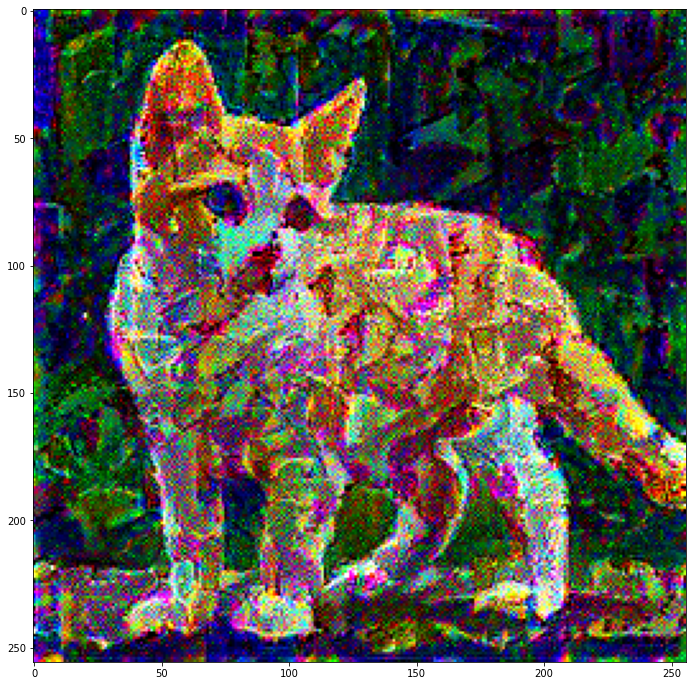

In [95]:
def variation_loss(img):
  img = tf.cast(img,tf.float32)
  x_var = img[ :, 1:, :] - img[ :, :-1, :]
  y_var = img[ 1:, :, :] - img[ :-1, :, :]
  return tf.reduce_sum(tf.abs(x_var)) + tf.reduce_sum(tf.abs(y_var))
  
def total_loss_var(img):
    return content_loss(img)+150*style_loss(img)+30*variation_loss(img)

img.assign(clip(np.random.normal(-0.3,0.3,size=img_content.shape)+img_content/255.0))

train(img,loss_fn=total_loss_var)

In [94]:
cv2.imwrite('result.jpg',(img.numpy()[:,:,::-1]*255))

(256, 256, 3)


True


---

**Omejitev odgovornosti**:  
Ta dokument je bil preveden z uporabo storitve za strojno prevajanje [Co-op Translator](https://github.com/Azure/co-op-translator). Čeprav si prizadevamo za natančnost, vas prosimo, da upoštevate, da lahko avtomatizirani prevodi vsebujejo napake ali netočnosti. Izvirni dokument v njegovem izvirnem jeziku je treba obravnavati kot avtoritativni vir. Za ključne informacije priporočamo strokovno človeško prevajanje. Ne prevzemamo odgovornosti za morebitna nesporazumevanja ali napačne razlage, ki izhajajo iz uporabe tega prevoda.
